In [3]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *

import warnings
warnings.filterwarnings('ignore')

In [4]:
pgroup = 'p23084'
run = 180

channel_list = [channel_Izero122, channel_posX_122, channel_posY_122]
norm = None
quantile = 0.7

data, rbk, meta = load_step_scan(pgroup, run, channel_list, quantile, norm=norm)
print (np.shape(data))
Int, errInt_low, errInt_high = unwrap_data(data, 0)
Posx, errPosx_low, errPosx_high = unwrap_data(data, 1)
Posy, errPosy_low, errPosy_high = unwrap_data(data, 2)

100%|██████████| 31/31 [00:00<00:00, 132.74it/s]

(3, 31, 3)
Loaded 31 steps
Loaded 31 steps
Loaded 31 steps


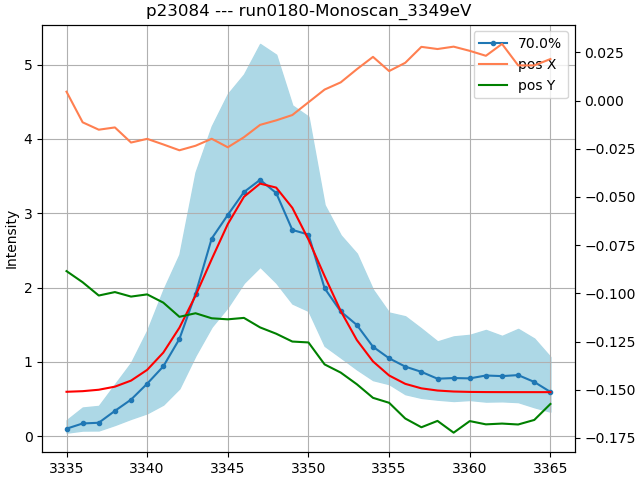

Center energy = 3347.271 eV
Width = 8.091 eV
Bandwidth = 0.242 %


In [5]:
# gaussian ---------------> [x0, amplitude, width, offset]

fit = Fit(gaussian, estimate_gaussian_parameters)
fit.estimate(rbk, Int)            # this sets some internal params 

#fit.p0 = better_p0(fit.p0, 0, 210.42) # overwrite some values (index) if needed: 

fit.fit(rbk, Int)                  # calculate the fit
ke_fit = fit.eval(rbk)            # evaluate the curve for plotting

centerpos = fit.popt[0]
width = fit.popt[2]*2.355

fig, ax1 = plt.subplots(constrained_layout=True)
ax2 = ax1.twinx()
plt.title(meta['title'])

l1 = ax1.plot(rbk, Int, label='{}%'.format(quantile*100),marker='.')
ax1.fill_between(rbk, errInt_low, errInt_high, color='lightblue')
ax1.plot(rbk, ke_fit, color='red')

#ax1.plot(psss_x_mean, psss_y_mean/np.max(psss_y_mean))

l2 = ax2.plot(rbk, Posx, color = 'coral', label='pos X')
l3 = ax2.plot(rbk, Posy, color = 'green', label='pos Y')

leg = l1+l2+l3
labels = [l.get_label() for l in leg]

plt.xlabel('{} ({})'.format(meta['xlabel'], meta['units']))
ax1.set_ylabel("Intensity")
#ax2.set_ylim(-0.1,0.6)
ax1.legend(leg, labels, loc='best')
#ax2.legend(loc="upper left")
ax1.grid()

plt.show()

print("Center energy = {:.3f} eV".format(centerpos))
print("Width = {:.3f} eV".format(width))
print("Bandwidth = {:.3f} %".format(100*np.abs(width)/centerpos))

In [4]:
import matplotlib.dates
from datetime import datetime

x_values = [datetime(2021, 5, 3), datetime(2021, 5, 6), datetime(2021, 5, 15), 
            datetime(2021, 11, 13), datetime(2021, 11, 30), datetime(2022, 5, 9),
            datetime(2022, 9, 11), datetime(2022, 9, 20), datetime(2022, 10, 10),
            datetime(2022, 10, 15), datetime(2022, 10, 25),datetime(2023, 1, 26), 
            datetime(2023, 1, 30), datetime(2023, 2, 27), datetime(2023, 11, 28),
            datetime(2024, 4, 30), datetime(2024, 10, 18), datetime(2025, 8, 19),
            datetime(2025, 9, 22), datetime(2026, 4, 27), datetime(2026, 4, 30),
            datetime(2026, 5, 26)]

y_values = [0.33, 0.32, 0.31, 0.25, 0.29, 0.34, 0.64, 0.53, 0.41, 0.45, 0.41, 0.44, 0.38, 0.48, 0.42, 0.32, 0.37, 0.2, 0.2, 0.298, 0.33, 0.38]

dates = matplotlib.dates.date2num(x_values)

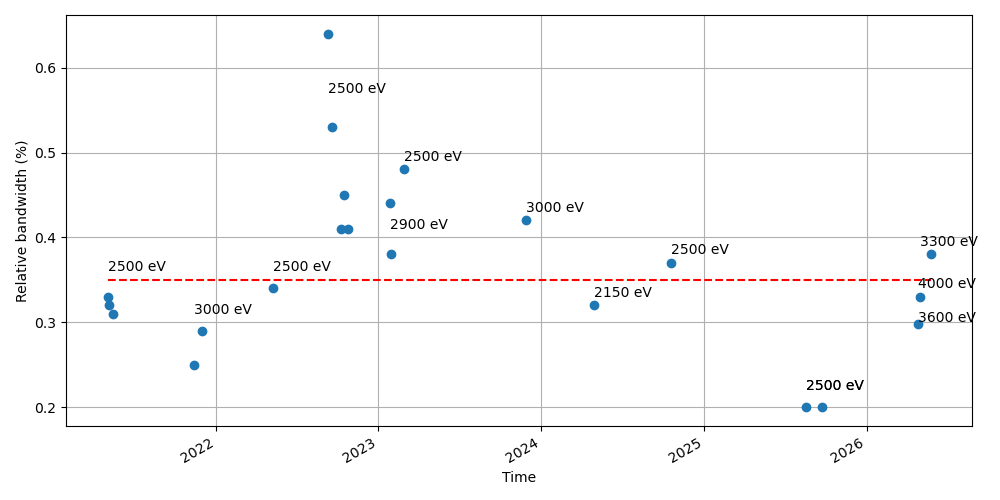

In [5]:
plt.figure(figsize=(10,5))
plt.plot_date(dates, y_values)
plt.gcf().autofmt_xdate()
plt.ylabel('Relative bandwidth (%)')
plt.xlabel('Time')
plt.text(x_values[0], 0.36, '2500 eV')
plt.text(x_values[3], 0.31, '3000 eV')
plt.text(x_values[5], 0.36, '2500 eV')
plt.text(x_values[6], 0.57, '2500 eV')
plt.text(x_values[11], 0.41, '2900 eV')
plt.text(x_values[13], 0.49, '2500 eV')
plt.text(x_values[14], 0.43, '3000 eV')
plt.text(x_values[15], 0.33, '2150 eV')
plt.text(x_values[16], 0.38, '2500 eV')
plt.text(x_values[17], 0.22, '2500 eV')
plt.text(x_values[17], 0.22, '2500 eV')
plt.text(x_values[19], 0.30, '3600 eV')
plt.text(x_values[19], 0.34, '4000 eV')
plt.text(x_values[20], 0.39, '3300 eV')



#plt.hlines(0.35, datetime(2021, 5, 1), datetime(2023, 12, 1), linestyles='dashed', color = 'red')
plt.hlines(0.35, x_values[0], x_values[-1], linestyles='dashed', color = 'red')
plt.grid()
plt.tight_layout()
plt.show()